# Adaptación del modelo LSTM de contraste a los datos de participación

Este cuaderno adapta la red LSTM construida en la asignatura Computación Emergente
—conservada en `LSTM/viejo/`— para que opere sobre el conjunto de datos estandarizado
de esta investigación. La red original clasificaba el resultado final de un curso en
cuatro categorías a partir de la actividad semanal en un entorno virtual; aquí debe
predecir una cantidad, la de participaciones de un estudiante a lo largo del trimestre,
a partir de lo observado hasta un momento determinado del período.

La adaptación afecta a tres piezas del modelo:

1. **La capa de entrada**, que pasa de recibir ocho variables sociodemográficas y una
   serie de veintiún semanas de clics, a recibir dos entradas paralelas: los rasgos
   numéricos de cada semana y el tema de cada sesión, este último a través de una capa
   que aprende una representación numérica de cada tema en lugar de imponerla.
2. **La capa de salida**, que pasa de producir una distribución sobre cuatro clases a
   producir un único valor continuo, entrenado sobre el objetivo estandarizado.
3. **El procedimiento de evaluación**, que pasa de una partición temporal única a una
   validación cruzada que deja un trimestre fuera en cada iteración, dado el volumen
   reducido del conjunto, y que compara siempre contra dos referencias sencillas.

Ambos modelos de la investigación —este y la red bayesiana— reciben la misma información
de entrada; lo que cambia entre ellos es cómo cada familia la representa internamente.

## Importaciones

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Reshape, Concatenate, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Semilla única para que el cuaderno sea reproducible entre ejecuciones
SEMILLA = 42
tf.keras.utils.set_random_seed(SEMILLA)

## Fase N. 1. Preparación de datos

El punto de partida son los archivos `.csv` que produce `preprocesamiento/generar_csv.py`,
uno por sección, en los que cada fila corresponde a un estudiante en una sesión de clase.
Conservan las etiquetas originales de los campos cualitativos, de modo que la conversión a
valores numéricos se realiza aquí, como paso previo a la entrada del modelo.

### 1.1. Carga de las secciones

In [2]:
def cargar_datos(carpeta):
    """Cargar y concatenar los archivos de todas las secciones.

    Parameters
    ----------
    carpeta : str or pathlib.Path
        Carpeta que contiene los archivos .csv, organizados por asignatura y trimestre.

    Returns
    -------
    pandas.DataFrame
        Tabla única con una fila por estudiante y sesión.
    """
    archivos = sorted(glob.glob(f"{carpeta}/**/*.csv", recursive=True))
    if not archivos:
        raise FileNotFoundError(f"No se encontraron archivos .csv en {carpeta}")
    tablas = [pd.read_csv(a) for a in archivos]
    print(f"{len(archivos)} secciones cargadas")
    return pd.concat(tablas, ignore_index=True)

In [3]:
# Localización de la carpeta de datos partiendo de la ubicación del cuaderno
RAIZ = Path.cwd()
while not (RAIZ / "Datos Tesis Downstream").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent

datos = cargar_datos(RAIZ / "Datos Tesis Downstream")
print(f"{len(datos)} filas, {datos.estudiante_id.nunique()} estudiantes distintos")
datos.head()

14 secciones cargadas
9612 filas, 392 estudiantes distintos


,numero_lista,estudiante_id,materia,trimestre,seccion,semana,dia_sesion,tema,tipo_sesion,participaciones,asistencia,anio_academico
0,1,anon_001,Algoritmos y Programación,2425-2,1,1,lunes,0,administrativa,1.0,1.0,1.0
1,1,anon_001,Algoritmos y Programación,2425-2,1,1,miercoles,1,contenido,0.0,NaN,1.0
2,1,anon_001,Algoritmos y Programación,2425-2,1,2,lunes,2,contenido,0.0,NaN,1.0
3,1,anon_001,Algoritmos y Programación,2425-2,1,2,miercoles,3,contenido,1.0,1.0,1.0
4,1,anon_001,Algoritmos y Programación,2425-2,1,3,lunes,4,contenido,0.0,NaN,1.0


### 1.2. Codificación numérica de los campos cualitativos

La estructura estándar conserva cinco campos como texto. La codificación sigue los
criterios de la Tabla 6 del informe: el trimestre y el día de la sesión son ordinales y
reciben un número que preserva su orden; la asignatura y el identificador del estudiante
son nominales y reciben un entero que solo los distingue, sin entrar como variable al
modelo; y el tipo de sesión, también nominal, se representa mediante una variable
indicadora por categoría para no imponer una jerarquía entre categorías equivalentes.

In [4]:
def codificar_campos_cualitativos(datos):
    """Convertir a valores numéricos los campos que la estructura estándar guarda como texto.

    El trimestre se convierte en un ordinal relativo al primero observado; el día de la
    sesión, en su posición dentro de la semana; la asignatura y el estudiante, en un
    identificador entero; y el tipo de sesión, en una variable indicadora por categoría.

    Parameters
    ----------
    datos : pandas.DataFrame
        Tabla con una fila por estudiante y sesión.

    Returns
    -------
    pandas.DataFrame
        La misma tabla con las columnas numéricas añadidas.
    """
    d = datos.copy()

    # Ordinales: conservan el orden del período y de la sesión dentro de la semana
    trimestres = sorted(d.trimestre.unique())
    d["trimestre_num"] = d.trimestre.map({t: i + 1 for i, t in enumerate(trimestres)})
    d["dia_num"] = d.dia_sesion.map({"lunes": 1, "martes": 1, "miercoles": 2, "jueves": 2})

    # Nominales de segmentación: distinguen sin ordenar y no entran como variable
    materias = sorted(d.materia.unique())
    d["materia_num"] = d.materia.map({m: i + 1 for i, m in enumerate(materias)})
    d["seccion_num"] = pd.to_numeric(d.seccion, errors="coerce")

    # Nominal sin orden: una variable indicadora por categoría
    for categoria in sorted(d.tipo_sesion.dropna().unique()):
        d[f"sesion_{categoria}"] = (d.tipo_sesion == categoria).astype(int)

    return d

In [5]:
# Aplicación de la codificación y comprobación de que no quedaron valores sin traducir
datos = codificar_campos_cualitativos(datos)

sin_traducir = datos[["trimestre_num", "dia_num", "materia_num"]].isna().sum()
print("valores sin traducir:", sin_traducir.to_dict())
print("trimestre:", dict(zip(sorted(datos.trimestre.unique()), sorted(datos.trimestre_num.unique()))))
print("indicadores de tipo de sesión:", [c for c in datos.columns if c.startswith("sesion_")])

valores sin traducir: {'trimestre_num': 0, 'dia_num': 0, 'materia_num': 0}
trimestre: {'2425-2': np.int64(1), '2425-3': np.int64(2), '2526-1': np.int64(3), '2526-2': np.int64(4), '2526-3': np.int64(5)}
indicadores de tipo de sesión: ['sesion_administrativa', 'sesion_contenido', 'sesion_evaluacion', 'sesion_repaso', 'sesion_sin_clase']


### 1.3. Agregación de las sesiones a la semana

La unidad temporal del modelo es la semana del trimestre, no la sesión. Esta decisión
tiene una razón práctica además de la conceptual: las dos secciones de Computación
Emergente 2425-3 se dictaron en una única sesión semanal, mientras el resto tuvo dos, de
modo que una secuencia por sesión tendría longitudes distintas según la sección. Agregar
a la semana da una secuencia de doce pasos para todas.

De cada semana se conservan cuatro rasgos numéricos —las participaciones registradas,
las sesiones a las que consta la asistencia, cuántas sesiones tuvo esa semana y cuántas
fueron de evaluación— y, por separado, el código de tema de cada una de sus dos sesiones,
porque en el 24% de las semanas las dos sesiones cubren temas distintos. Cuando la
semana tuvo una sola sesión, o la sesión no cubrió contenido nuevo, el código es 0.

In [6]:
CLAVES = ["materia", "trimestre", "seccion", "estudiante_id"]


def agregar_por_semana(datos):
    """Resumir las sesiones de cada semana en una única fila por estudiante y semana.

    Parameters
    ----------
    datos : pandas.DataFrame
        Tabla con una fila por estudiante y sesión, ya codificada.

    Returns
    -------
    pandas.DataFrame
        Tabla con una fila por estudiante y semana del trimestre, con los rasgos
        numéricos y el código de tema de la primera y de la segunda sesión.
    """
    # El tema solo cuenta en las sesiones de contenido; en las demás vale 0
    d = datos.copy()
    d["tema_contenido"] = np.where(d.tipo_sesion == "contenido", d.tema.fillna(0), 0).astype(int)

    semanal = d.groupby(CLAVES + ["semana"], as_index=False).agg(
        participaciones=("participaciones", "sum"),
        asistencia=("asistencia", lambda s: s.fillna(0).sum()),
        sesiones=("dia_num", "size"),
        evaluaciones=("sesion_evaluacion", "sum"),
    )

    # Tema de cada sesión, ordenadas por su posición en la semana
    temas = (d.sort_values("dia_num")
             .groupby(CLAVES + ["semana"]).tema_contenido
             .apply(lambda s: list(s)[:2] + [0] * (2 - len(list(s)[:2])))
             .apply(pd.Series))
    temas.columns = ["tema_1", "tema_2"]
    return semanal.merge(temas.reset_index(), on=CLAVES + ["semana"], how="left")

In [7]:
# Agregación de las sesiones a la semana
semanal = agregar_por_semana(datos)
print(f"{len(semanal)} filas de estudiante-semana")
print("sesiones por semana:", semanal.sesiones.value_counts().to_dict())
print("códigos de tema distintos (incluido el 0):",
      len(set(semanal.tema_1) | set(semanal.tema_2)))
semanal.head()

5244 filas de estudiante-semana
sesiones por semana: {2: 4368, 1: 876}
códigos de tema distintos (incluido el 0): 14


,materia,trimestre,seccion,estudiante_id,semana,participaciones,asistencia,sesiones,evaluaciones,tema_1,tema_2
0,Algoritmos y Programación,2425-2,1,anon_001,1,1.0,1.0,2,0,0,1
1,Algoritmos y Programación,2425-2,1,anon_001,2,1.0,1.0,2,0,2,3
2,Algoritmos y Programación,2425-2,1,anon_001,3,0.0,0.0,2,0,4,4
3,Algoritmos y Programación,2425-2,1,anon_001,4,0.0,0.0,2,0,5,0
4,Algoritmos y Programación,2425-2,1,anon_001,5,0.0,0.0,2,1,0,6


### 1.4. Variables estáticas

Son las que no cambian a lo largo del trimestre y se replican en cada paso temporal. La
matriz de operacionalización las clasifica como estáticas o contextuales: el año que cursa
el estudiante, la sección, el tamaño del grupo y la posición en la lista (número de lista
dividido entre el tamaño del grupo, para que sea comparable entre secciones). Los tres registros sin carnet, para los
que el año académico no pudo derivarse, se completan con la mediana del conjunto.

In [8]:
def construir_tabla_estatica(datos):
    """Reunir en una fila por estudiante-sección las variables que no varían en el trimestre.

    Parameters
    ----------
    datos : pandas.DataFrame
        Tabla con una fila por estudiante y sesión, ya codificada.

    Returns
    -------
    pandas.DataFrame
        Tabla con una fila por registro estudiante-sección.
    """
    estatica = datos.groupby(CLAVES, as_index=False).agg(
        anio_academico=("anio_academico", "first"),
        seccion_num=("seccion_num", "first"),
        numero_lista=("numero_lista", "first"),
        trimestre_num=("trimestre_num", "first"),
        materia_num=("materia_num", "first"),
    )

    # El tamaño del grupo es una propiedad de la sección, no del estudiante
    tamano = (datos.groupby(["materia", "trimestre", "seccion"]).estudiante_id
              .nunique().rename("tamano_grupo").reset_index())
    estatica = estatica.merge(tamano, on=["materia", "trimestre", "seccion"], how="left")
    # Posición relativa en la lista: comparable entre secciones de distinto tamaño
    estatica["posicion_lista"] = estatica.numero_lista / estatica.tamano_grupo

    faltantes = int(estatica.anio_academico.isna().sum())
    if faltantes:
        estatica["anio_academico"] = estatica.anio_academico.fillna(estatica.anio_academico.median())
        print(f"{faltantes} registros sin año académico completados con la mediana")

    return estatica.sort_values(CLAVES).reset_index(drop=True)

In [9]:
# Construcción de la tabla de variables estáticas
estatica = construir_tabla_estatica(datos)
print(f"{len(estatica)} registros estudiante-sección")
print(estatica.groupby("materia").size().to_string())
estatica.head()

3 registros sin año académico completados con la mediana
437 registros estudiante-sección
materia
Algoritmos y Programación    147
Computación Emergente        182
Estructura de Datos          108


,materia,trimestre,seccion,estudiante_id,anio_academico,seccion_num,trimestre_num,materia_num,tamano_grupo
0,Algoritmos y Programación,2425-2,1,anon_001,1.0,1,1,1,30
1,Algoritmos y Programación,2425-2,1,anon_002,1.0,1,1,1,30
2,Algoritmos y Programación,2425-2,1,anon_003,1.0,1,1,1,30
3,Algoritmos y Programación,2425-2,1,anon_004,1.0,1,1,1,30
4,Algoritmos y Programación,2425-2,1,anon_005,1.0,1,1,1,30


## Fase N. 2. Modelado

### 2.1. Construcción de los tensores de entrada

La organización de los datos en secuencias temporales se conserva, porque es
precisamente lo que justifica emplear una red LSTM como modelo de contraste. Cambia el
contenido de cada secuencia: cada registro estudiante-sección se representa como doce
pasos, uno por semana.

Se construyen dos tensores alineados fila a fila. El primero reúne, en cada paso, las
variables estáticas replicadas y los cuatro rasgos numéricos de la semana. El segundo
reúne los dos códigos de tema de la semana, que la red tratará como categorías y no como
cantidades. La variable objetivo es la cantidad de participaciones del estudiante en
todo el trimestre, tal como la define la matriz de operacionalización.

In [10]:
ESTATICAS = ["anio_academico", "seccion_num", "tamano_grupo", "posicion_lista"]
DINAMICAS = ["participaciones", "asistencia", "sesiones", "evaluaciones"]
N_SEMANAS = 12
N_TEMAS = 14          # códigos 0 a 13 del catálogo (Estructura de Datos fija el máximo); el 0 señala ausencia de contenido


def construir_tensor_3d(semanal, estatica):
    """Construir los tensores de entrada y el vector objetivo.

    Cada registro estudiante-sección ocupa una fila y se despliega en doce pasos
    temporales. El tensor numérico replica las variables estáticas y coloca los rasgos
    de la semana; el tensor de temas coloca los códigos de sus dos sesiones. El objetivo
    es la suma de participaciones del trimestre.

    Parameters
    ----------
    semanal : pandas.DataFrame
        Tabla con una fila por estudiante y semana.
    estatica : pandas.DataFrame
        Tabla con una fila por registro estudiante-sección.

    Returns
    -------
    tuple
        (tensor numérico (registros, semanas, características),
         tensor de temas (registros, semanas, 2), vector objetivo).
    """
    n_estaticas = len(ESTATICAS)
    numerico = np.zeros((len(estatica), N_SEMANAS, n_estaticas + len(DINAMICAS)), dtype=np.float32)
    temas = np.zeros((len(estatica), N_SEMANAS, 2), dtype=np.int32)

    # Replicación de las variables estáticas en cada paso temporal
    numerico[:, :, :n_estaticas] = estatica[ESTATICAS].to_numpy(dtype=np.float32)[:, None, :]

    # Colocación de los rasgos y los temas de cada semana en su paso
    indice = {clave: i for i, clave in
              enumerate(estatica[CLAVES].itertuples(index=False, name=None))}
    for fila in semanal.itertuples(index=False):
        i = indice[(fila.materia, fila.trimestre, fila.seccion, fila.estudiante_id)]
        paso = int(fila.semana) - 1
        numerico[i, paso, n_estaticas:] = (fila.participaciones, fila.asistencia,
                                           fila.sesiones, fila.evaluaciones)
        temas[i, paso] = (fila.tema_1, fila.tema_2)

    # Objetivo: participaciones acumuladas en todo el trimestre
    objetivo = (semanal.groupby(CLAVES).participaciones.sum()
                .reindex(list(indice)).to_numpy(dtype=np.float32))

    return numerico, temas, objetivo

In [11]:
# Construcción de los tensores y comprobación de su coherencia
X, X_temas, y = construir_tensor_3d(semanal, estatica)
print(f"tensor numérico: {X.shape}   tensor de temas: {X_temas.shape}   objetivo: {y.shape}")
print(f"características numéricas: {ESTATICAS + DINAMICAS}")
print(f"objetivo -> media {y.mean():.2f}, desviación {y.std():.2f}, máximo {y.max():.0f}, "
      f"ceros {int((y == 0).sum())} de {len(y)}")

assert not np.isnan(X).any() and not np.isnan(y).any(), "quedan valores ausentes"
assert np.isclose(X[:, :, len(ESTATICAS)].sum(), y.sum()), "el objetivo no cuadra con el tensor"
assert X_temas.max() < N_TEMAS, "hay un código de tema fuera del vocabulario"
print("comprobaciones superadas")

tensor numérico: (437, 12, 7)   tensor de temas: (437, 12, 2)   objetivo: (437,)
características numéricas: ['anio_academico', 'seccion_num', 'tamano_grupo', 'participaciones', 'asistencia', 'sesiones', 'evaluaciones']
objetivo -> media 4.27, desviación 6.26, máximo 44, ceros 147 de 437
comprobaciones superadas


### 2.2. Truncamiento por hito temporal y objetivo de la red

Si la red recibiera las doce semanas completas, predecir el total del trimestre sería
sumar la propia entrada. El interés del modelo está en anticiparlo, de modo que la
secuencia se trunca en un hito y el modelo debe estimar el total a partir de lo observado
hasta ese momento. Se emplean tres hitos, en las semanas 4, 6 y 8; no se usa la semana 12
porque a esa altura el total ya sería directamente observable.

Lo observado hasta el hito es la variable que la matriz de operacionalización llama
frecuencia previa de participación, y el modelo la recibe de forma explícita: la red no
predice el total sino **las participaciones que faltan** desde el hito hasta el final del
trimestre, y el total se obtiene sumando ese pronóstico al acumulado ya observado. Así la
red no gasta capacidad en aprender a sumar lo que ya se sabe y la dedica a lo que queda
por ocurrir. Las métricas se calculan siempre sobre el total, que es la variable objetivo
declarada.

In [12]:
HITOS = [4, 6, 8]


def truncar_a_hito(tensor, hito):
    """Conservar únicamente las semanas transcurridas hasta el hito.

    Parameters
    ----------
    tensor : numpy.ndarray
        Tensor 3D completo, de doce pasos temporales (numérico o de temas).
    hito : int
        Número de la semana hasta la que se observa, inclusive.

    Returns
    -------
    numpy.ndarray
        Tensor truncado, de forma (registros, hito, ...).
    """
    return tensor[:, :hito]

In [13]:
# Relación entre lo observado en cada hito y el total del trimestre
for hito in HITOS:
    acumulado = truncar_a_hito(X, hito)[:, :, len(ESTATICAS)].sum(axis=1)
    print(f"semana {hito:>2}: se ha observado el {acumulado.sum() / y.sum():.0%} de las "
          f"participaciones del trimestre; correlación con el total r = "
          f"{np.corrcoef(acumulado, y)[0, 1]:.2f}")

semana  4: se ha observado el 47% de las participaciones del trimestre; correlación con el total r = 0.87
semana  6: se ha observado el 59% de las participaciones del trimestre; correlación con el total r = 0.92
semana  8: se ha observado el 76% de las participaciones del trimestre; correlación con el total r = 0.95


### 2.3. Arquitectura adaptada

Se conserva la estructura de dos capas LSTM con regularización, porque es lo que se
retoma del modelo de contraste, y se modifican tres cosas.

La **capa de entrada** se desdobla en dos. Los rasgos numéricos entran como hasta ahora.
Los códigos de tema entran por una capa de *embedding*: cada uno de los 14 códigos recibe
un vector de dos números que la red ajusta durante el entrenamiento, de modo que temas en
los que los estudiantes participan de forma parecida acaban con vectores parecidos. Se
elige esta representación y no una variable indicadora por categoría porque, con 13
temas en el catálogo más extenso, los indicadores elevarían los parámetros en un 45%; el
*embedding* lo hace en un 8%. Las dos sesiones de la semana comparten la misma tabla de vectores, para que un
tema signifique lo mismo caiga en la sesión que caiga. Ambas entradas se concatenan en un
único tensor por paso temporal antes de la primera LSTM.

La **capa de salida** pasa de una densa de cuatro unidades con activación *softmax* a
una densa de una unidad con activación lineal, y la pérdida pasa de entropía cruzada
categórica a error cuadrático medio.

El **número de unidades** se reduce de 64 a 16. El modelo original ajustaba 52.228
parámetros sobre 32.593 secuencias; conservar esa capacidad sobre 437 registros supondría
más de cien parámetros por observación.

In [14]:
def construir_modelo_lstm(hito, n_numericas, n_temas=N_TEMAS, dim_tema=2,
                          unidades=16, tasa_aprendizaje=0.001):
    """Construir y compilar la red LSTM adaptada, con dos entradas.

    Parameters
    ----------
    hito : int
        Número de pasos temporales que recibe la red.
    n_numericas : int
        Número de características numéricas por paso.
    n_temas : int
        Tamaño del vocabulario de códigos de tema.
    dim_tema : int
        Dimensión del vector aprendido para cada tema.
    unidades : int
        Número de unidades de cada capa LSTM.
    tasa_aprendizaje : float
        Tasa de aprendizaje usada por el optimizador Adam.

    Returns
    -------
    tensorflow.keras.Model
        Modelo compilado, que recibe la lista [numéricas, temas].
    """
    entrada_numerica = Input(shape=(hito, n_numericas), name="numericas")
    entrada_temas = Input(shape=(hito, 2), dtype="int32", name="temas")

    # Cada código de tema se sustituye por un vector aprendido; la misma tabla
    # sirve para las dos sesiones de la semana
    vectores = Embedding(n_temas, dim_tema, name="vectores_tema")(entrada_temas)
    vectores = Reshape((hito, 2 * dim_tema))(vectores)
    
    secuencia = Concatenate(axis=-1)([entrada_numerica, vectores])
    x = LSTM(unidades, return_sequences=True)(secuencia)
    x = Dropout(0.3)(x)
    x = LSTM(unidades)(x)
    x = Dropout(0.3)(x)
    salida = Dense(1, activation="linear")(x)

    modelo = Model(inputs=[entrada_numerica, entrada_temas], outputs=salida)
    modelo.compile(
        optimizer=Adam(learning_rate=tasa_aprendizaje),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return modelo

In [15]:
# Instanciación de referencia sobre el hito más temprano, para revisar la arquitectura
modelo_referencia = construir_modelo_lstm(HITOS[0], X.shape[2])
modelo_referencia.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temas (InputLayer)  │ (None, 4, 2)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectores_tema       │ (None, 4, 2, 2)   │         28 │ temas[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numericas           │ (None, 4, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4)      │          0 │ vectores_tema[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 11)     │          0 │ numericas[0][0],  │
│ (Concatenate)       │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 4, 16)     │      1,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4, 16)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      2,112 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         17 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,949 (15.43 KB)

 Trainable params: 3,949 (15.43 KB)

 Non-trainable params: 0 (0.00 B)

### 2.4. Escalado

Las características numéricas se estandarizan por columna, ajustando el escalador
únicamente con el conjunto de entrenamiento de cada iteración para no filtrar
información del conjunto de prueba. Los códigos de tema no se escalan: son categorías,
no magnitudes, y la capa de *embedding* los recibe tal cual.

El **objetivo también se estandariza** durante el entrenamiento y se devuelve a su escala
al predecir. Las participaciones del trimestre van de 0 a 44, y una salida lineal que
parte de cero tarda en alcanzar esa escala con pocos ejemplos; sin este paso la red
tiende a quedarse cerca de la media.

In [16]:
def escalar_caracteristicas(X_entrenamiento, X_prueba):
    """Estandarizar el tensor numérico ajustando el escalador solo con entrenamiento.

    Parameters
    ----------
    X_entrenamiento : numpy.ndarray
        Tensor 3D numérico de entrenamiento.
    X_prueba : numpy.ndarray
        Tensor 3D numérico de prueba, con los mismos pasos y características.

    Returns
    -------
    tuple
        (X de entrenamiento escalado, X de prueba escalado).
    """
    pasos, caracteristicas = X_entrenamiento.shape[1], X_entrenamiento.shape[2]
    escalador = StandardScaler()
    entrenamiento = escalador.fit_transform(X_entrenamiento.reshape(-1, caracteristicas))
    prueba = escalador.transform(X_prueba.reshape(-1, caracteristicas))
    return (entrenamiento.reshape(-1, pasos, caracteristicas),
            prueba.reshape(-1, pasos, caracteristicas))


def escalar_objetivo(y_entrenamiento):
    """Devolver la media y la desviación del objetivo de entrenamiento.

    Parameters
    ----------
    y_entrenamiento : numpy.ndarray
        Objetivo del conjunto de entrenamiento.

    Returns
    -------
    tuple
        (media, desviación), con la desviación acotada para evitar divisiones por cero.
    """
    return float(y_entrenamiento.mean()), float(max(y_entrenamiento.std(), 1e-6))

## Fase N. 3. Entrenamiento y evaluación

### 3.1. Métricas

Al pasar de clasificación a predicción de una cantidad, las métricas cambian por completo.
Se reportan la raíz del error cuadrático medio y el coeficiente de determinación, que son
las declaradas en el diseño de la investigación, y se añade el error absoluto medio por
ser directamente interpretable en número de participaciones.

In [17]:
def calcular_metricas(y_real, y_predicho):
    """Calcular las métricas de una tarea de predicción de una cantidad.

    Parameters
    ----------
    y_real : numpy.ndarray
        Valores observados.
    y_predicho : numpy.ndarray
        Valores estimados por el modelo.

    Returns
    -------
    dict
        Diccionario con RMSE, MAE y coeficiente de determinación.
    """
    y_real = np.asarray(y_real, dtype=float).ravel()
    y_predicho = np.asarray(y_predicho, dtype=float).ravel()
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_real, y_predicho))),
        "mae": float(mean_absolute_error(y_real, y_predicho)),
        "r2": float(r2_score(y_real, y_predicho)),
    }

### 3.2. Líneas base

Un coeficiente de determinación alto no dice nada por sí solo si la tarea admite una
solución trivial. Aquí sí la admite en buena medida: quien ha participado mucho en las
primeras semanas tiende a participar mucho en el resto. Por eso se comparan dos
referencias sencillas contra las que el modelo debe demostrar que aporta algo.

La primera predice para todos la media del conjunto de entrenamiento, y sirve de suelo:
su coeficiente de determinación ronda el cero por construcción. La segunda extrapola de
forma proporcional lo observado hasta el hito, multiplicándolo por las doce semanas y
dividiéndolo entre las transcurridas. Es una referencia exigente, y dispone exactamente de
la misma información que la red: el acumulado hasta el hito.

In [18]:
def lineas_base(X_entrenamiento, y_entrenamiento, X_prueba, hito):
    """Calcular las predicciones de las dos referencias sencillas.

    Parameters
    ----------
    X_entrenamiento, X_prueba : numpy.ndarray
        Tensores sin escalar, truncados al hito.
    y_entrenamiento : numpy.ndarray
        Objetivo del conjunto de entrenamiento.
    hito : int
        Semana hasta la que se observa.

    Returns
    -------
    dict
        Predicciones de cada referencia sobre el conjunto de prueba.
    """
    columna_participaciones = len(ESTATICAS)
    acumulado = X_prueba[:, :, columna_participaciones].sum(axis=1)
    return {
        "media": np.full(len(X_prueba), y_entrenamiento.mean(), dtype=float),
        "extrapolación": acumulado * (N_SEMANAS / hito),
    }

### 3.3. Validación cruzada dejando un trimestre fuera

El conjunto reúne 437 registros repartidos en tres asignaturas, así que una partición
única dejaría un conjunto de prueba demasiado pequeño para que sus métricas signifiquen
algo. En su lugar se recorre cada trimestre como conjunto de prueba, entrenando con los
restantes, y se acumulan las predicciones de todas las iteraciones para calcular las
métricas una sola vez sobre el conjunto completo.

El criterio de partición sigue siendo el trimestre, como en el modelo original lo era el
año de la presentación del curso: el modelo nunca se evalúa sobre un período que haya
visto durante el entrenamiento.

In [19]:
def validacion_cruzada(X, X_temas, y, trimestres, hito, unidades=16, epocas=150, lote=16,
                       verbose=0, semilla=SEMILLA):
    """Evaluar el modelo dejando fuera un trimestre en cada iteración.

    La red se entrena para predecir las participaciones restantes tras el hito; el total
    que se evalúa es el acumulado observado más esa predicción.

    Parameters
    ----------
    X : numpy.ndarray
        Tensor numérico completo, sin truncar.
    X_temas : numpy.ndarray
        Tensor de códigos de tema completo, alineado con X.
    y : numpy.ndarray
        Vector objetivo: participaciones totales del trimestre.
    trimestres : numpy.ndarray
        Trimestre al que pertenece cada registro, usado para formar las particiones.
    hito : int
        Semana hasta la que se observa.
    unidades : int
        Unidades de cada capa LSTM.
    epocas, lote : int
        Épocas máximas y tamaño del lote.
    verbose : int
        Verbosidad que se pasa al entrenamiento de Keras.
    semilla : int
        Semilla con que se inicializan los pesos en cada iteración.

    Returns
    -------
    dict
        Predicciones acumuladas del modelo y de las líneas base, con los valores reales.
    """
    X_hito, T_hito = truncar_a_hito(X, hito), truncar_a_hito(X_temas, hito)
    acumulado = X_hito[:, :, len(ESTATICAS)].sum(axis=1)
    restantes = y - acumulado
    reales, del_modelo, de_base = [], [], {"media": [], "extrapolación": []}

    for periodo in sorted(np.unique(trimestres)):
        prueba = trimestres == periodo
        entrenamiento = ~prueba
        if prueba.sum() < 10 or entrenamiento.sum() < 30:
            print(f"  trimestre {periodo}: {prueba.sum()} registros, se omite por tamaño")
            continue

        # Las referencias se calculan sobre los datos sin escalar
        for nombre, prediccion in lineas_base(X_hito[entrenamiento], y[entrenamiento],
                                              X_hito[prueba], hito).items():
            de_base[nombre].append(prediccion)

        X_ent, X_pru = escalar_caracteristicas(X_hito[entrenamiento], X_hito[prueba])
        media, desviacion = escalar_objetivo(restantes[entrenamiento])

        tf.keras.utils.set_random_seed(semilla)
        modelo = construir_modelo_lstm(hito, X.shape[2], unidades=unidades)
        modelo.fit(
            [X_ent, T_hito[entrenamiento]], (restantes[entrenamiento] - media) / desviacion,
            epochs=epocas, batch_size=lote, validation_split=0.15, verbose=verbose,
            callbacks=[EarlyStopping(monitor="val_loss", patience=20,
                                     restore_best_weights=True)],
        )

        prediccion = modelo.predict([X_pru, T_hito[prueba]], verbose=0).ravel()
        del_modelo.append(acumulado[prueba] + prediccion * desviacion + media)
        reales.append(y[prueba])

    return {
        "real": np.concatenate(reales),
        "modelo": np.concatenate(del_modelo),
        **{nombre: np.concatenate(v) for nombre, v in de_base.items() if v},
    }

### 3.4. Entrenamiento por asignatura y hito

El sistema se implementa a nivel de asignatura, de modo que se entrena un modelo por
asignatura y por hito. Cada asignatura aporta entre 108 y 182 registros repartidos en
cuatro trimestres.

In [20]:
# Entrenamiento de un modelo por asignatura y por hito. Puede tardar varios minutos.
resultados = []
predicciones = {}

for materia in sorted(estatica.materia.unique()):
    filas = (estatica.materia == materia).to_numpy()
    trimestres = estatica.trimestre.to_numpy()[filas]
    print(f"\n=== {materia}: {filas.sum()} registros, "
          f"{len(np.unique(trimestres))} trimestres ===")

    for hito in HITOS:
        salida = validacion_cruzada(X[filas], X_temas[filas], y[filas], trimestres, hito)
        predicciones[(materia, hito)] = salida

        for fuente in ("modelo", "media", "extrapolación"):
            if fuente in salida:
                metricas = calcular_metricas(salida["real"], salida[fuente])
                resultados.append({"materia": materia, "hito": hito,
                                   "fuente": fuente, **metricas})

        m = calcular_metricas(salida["real"], salida["modelo"])
        print(f"  hito {hito:>2} -> RMSE {m['rmse']:.2f}  MAE {m['mae']:.2f}  R² {m['r2']:.3f}")

resultados = pd.DataFrame(resultados)
print(f"\n{len(resultados)} filas de resultados")


=== Algoritmos y Programación: 147 registros, 4 trimestres ===
  hito  4 -> RMSE 3.71  MAE 2.79  R² 0.595
  hito  6 -> RMSE 3.02  MAE 2.16  R² 0.731
  hito  8 -> RMSE 1.23  MAE 0.84  R² 0.956

=== Computación Emergente: 182 registros, 4 trimestres ===
  hito  4 -> RMSE 2.60  MAE 1.75  R² 0.767
  hito  6 -> RMSE 2.28  MAE 1.34  R² 0.820
  hito  8 -> RMSE 1.21  MAE 0.68  R² 0.949

=== Estructura de Datos: 108 registros, 4 trimestres ===
  hito  4 -> RMSE 6.63  MAE 4.78  R² 0.271
  hito  6 -> RMSE 4.87  MAE 3.37  R² 0.607
  hito  8 -> RMSE 3.95  MAE 2.71  R² 0.741

27 filas de resultados


### 3.5. Exploración del número de unidades

La reducción de 64 a 16 unidades responde al volumen del conjunto, pero conviene
comprobarla en lugar de darla por buena. Se comparan tres tamaños sobre el hito
intermedio, con el resto de la configuración fija.

In [21]:
# Comparación de tamaños de capa sobre el hito intermedio
comparacion = []
hito_medio = HITOS[1]

for unidades in (8, 16, 32):
    for materia in sorted(estatica.materia.unique()):
        filas = (estatica.materia == materia).to_numpy()
        salida = validacion_cruzada(X[filas], X_temas[filas], y[filas],
                                    estatica.trimestre.to_numpy()[filas],
                                    hito_medio, unidades=unidades)
        comparacion.append({"unidades": unidades, "materia": materia,
                            **calcular_metricas(salida["real"], salida["modelo"])})

comparacion = pd.DataFrame(comparacion)
print(comparacion.groupby("unidades")[["rmse", "mae", "r2"]].mean().round(3).to_string())

           rmse    mae     r2
unidades                     
8         3.191  2.225  0.750
16        3.389  2.292  0.719
32        2.893  1.948  0.795


### 3.6. Variabilidad entre semillas

Con un centenar de registros por asignatura, la inicialización aleatoria de los pesos puede
mover las métricas. Para saber cuánto, se repite el barrido completo de la sección 3.4 con
cinco semillas distintas y se reporta la media y la desviación de cada combinación. Una
desviación pequeña frente a la diferencia con la extrapolación indica que la ventaja del
modelo no depende de la suerte de una semilla. Tarda unas cinco veces lo que la sección 3.4.

In [22]:
# Repetición del barrido con cinco semillas
SEMILLAS = [42, 7, 123, 2024, 31]

filas_semillas = []
for semilla in SEMILLAS:
    for materia in sorted(estatica.materia.unique()):
        filas = (estatica.materia == materia).to_numpy()
        trimestres = estatica.trimestre.to_numpy()[filas]
        for hito in HITOS:
            salida = validacion_cruzada(X[filas], X_temas[filas], y[filas], trimestres, hito,
                                        semilla=semilla)
            metricas = calcular_metricas(salida["real"], salida["modelo"])
            filas_semillas.append({"semilla": semilla, "materia": materia, "hito": hito, **metricas})
    print(f"semilla {semilla} terminada")

semillas = pd.DataFrame(filas_semillas)

semilla 42 terminada
semilla 7 terminada
semilla 123 terminada
semilla 2024 terminada
semilla 31 terminada


In [23]:
# Media y desviación por asignatura e hito, junto a la extrapolación (que no depende de semilla)
resumen = semillas.groupby(["materia", "hito"])[["rmse", "r2"]].agg(["mean", "std"])
resumen.columns = ["rmse_media", "rmse_desv", "r2_media", "r2_desv"]

extrapolacion = (resultados[resultados.fuente == "extrapolación"]
                 .set_index(["materia", "hito"])[["rmse", "r2"]]
                 .rename(columns={"rmse": "rmse_extrapolación", "r2": "r2_extrapolación"}))
resumen = resumen.join(extrapolacion).round(3)

# Texto "media ± desviación" listo para el informe
resumen["RMSE modelo"] = resumen.rmse_media.map("{:.2f}".format) + " ± " + resumen.rmse_desv.map("{:.2f}".format)
resumen["R² modelo"] = resumen.r2_media.map("{:.3f}".format) + " ± " + resumen.r2_desv.map("{:.3f}".format)

mejora = (resumen.rmse_media < resumen.rmse_extrapolación)
print(f"el modelo mejora la extrapolación, en promedio, en {int(mejora.sum())} de {len(mejora)} combinaciones\n")
resumen[["RMSE modelo", "rmse_extrapolación", "R² modelo", "r2_extrapolación"]]

el modelo mejora la extrapolación, en promedio, en 5 de 9 combinaciones



RMSE modelo  rmse_extrapolación  \
materia                   hito                                    
Algoritmos y Programación 4     3.45 ± 0.33               5.702   
                          6     2.69 ± 0.44               3.290   
                          8     1.27 ± 0.05               2.804   
Computación Emergente     4     2.67 ± 0.12               3.877   
                          6     2.38 ± 0.12               2.110   
                          8     1.37 ± 0.21               1.468   
Estructura de Datos       4     6.24 ± 0.50               5.743   
                          6     4.54 ± 0.21               3.894   
                          8     3.72 ± 0.16               2.829   

                                    R² modelo  r2_extrapolación  
materia                   hito                                   
Algoritmos y Programación 4     0.647 ± 0.067             0.044  
                          6     0.783 ± 0.073             0.682  
                          8     0.953 ± 0.004             0.769  
Computación Emergente     4     0.753 ± 0.021             0.480  
                          6     0.804 ± 0.020             0.846  
                          8     0.934 ± 0.021             0.925  
Estructura de Datos       4     0.351 ± 0.103             0.452  
                          6     0.657 ± 0.031             0.748  
                          8     0.770 ± 0.020             0.867

In [24]:
# Registro de los resultados por semilla junto al cuaderno
semillas.round(4).to_csv(Path.cwd() / "metricas_semillas.csv", index=False)
resumen.round(4).to_csv(Path.cwd() / "metricas_semillas_resumen.csv")
print("guardados metricas_semillas.csv y metricas_semillas_resumen.csv")

guardados metricas_semillas.csv y metricas_semillas_resumen.csv


## Fase N. 4. Análisis

### 4.1. Resultados por asignatura e hito

La tabla enfrenta el modelo con las dos referencias. La lectura pertinente no es el valor
absoluto del coeficiente de determinación, sino si el modelo mejora la extrapolación
proporcional: si no lo hace, la red no está aportando nada que no estuviera ya en el
conteo acumulado.

In [25]:
# Comparación del modelo con las dos referencias, por asignatura e hito
tabla = resultados.pivot_table(index=["materia", "hito"], columns="fuente",
                               values="rmse").round(2)
tabla.columns = [f"RMSE {c}" for c in tabla.columns]
tabla["R² modelo"] = resultados[resultados.fuente == "modelo"].set_index(
    ["materia", "hito"]).r2.round(3)
tabla["R² extrapolación"] = resultados[resultados.fuente == "extrapolación"].set_index(
    ["materia", "hito"]).r2.round(3)
tabla

RMSE extrapolación  RMSE media  RMSE modelo  \
materia                   hito                                                
Algoritmos y Programación 4                   5.70        6.12         3.71   
                          6                   3.29        6.12         3.02   
                          8                   2.80        6.12         1.23   
Computación Emergente     4                   3.88        5.79         2.60   
                          6                   2.11        5.79         2.28   
                          8                   1.47        5.79         1.21   
Estructura de Datos       4                   5.74        7.85         6.63   
                          6                   3.89        7.85         4.87   
                          8                   2.83        7.85         3.95   

                                R² modelo  R² extrapolación  
materia                   hito                               
Algoritmos y Programación 4         0.595             0.044  
                          6         0.731             0.682  
                          8         0.956             0.769  
Computación Emergente     4         0.767             0.480  
                          6         0.820             0.846  
                          8         0.949             0.925  
Estructura de Datos       4         0.271             0.452  
                          6         0.607             0.748  
                          8         0.741             0.867

In [26]:
# Diferencia del modelo respecto de la extrapolación: negativo significa que mejora
resumen = resultados.pivot_table(index=["materia", "hito"], columns="fuente", values="rmse")
resumen["mejora_rmse"] = (resumen["modelo"] - resumen["extrapolación"]).round(2)
print(resumen[["modelo", "extrapolación", "mejora_rmse"]].round(2).to_string())
print(f"\nel modelo mejora la extrapolación en "
      f"{(resumen.mejora_rmse < 0).sum()} de {len(resumen)} combinaciones")

fuente                          modelo  extrapolación  mejora_rmse
materia                   hito                                    
Algoritmos y Programación 4       3.71           5.70        -1.99
                          6       3.02           3.29        -0.27
                          8       1.23           2.80        -1.58
Computación Emergente     4       2.60           3.88        -1.28
                          6       2.28           2.11         0.17
                          8       1.21           1.47        -0.25
Estructura de Datos       4       6.63           5.74         0.88
                          6       4.87           3.89         0.97
                          8       3.95           2.83         1.12

el modelo mejora la extrapolación en 5 de 9 combinaciones


### 4.2. Evolución del error a lo largo del trimestre

Se espera que el error disminuya conforme avanza el trimestre, sencillamente porque el
modelo dispone de más semanas observadas. El gráfico muestra esa evolución y permite
identificar a partir de qué momento la predicción alcanza una precisión útil para el
docente.

In [27]:
def graficar_evolucion(resultados):
    """Representar el RMSE de cada asignatura a lo largo de los hitos.

    Parameters
    ----------
    resultados : pandas.DataFrame
        Tabla con las métricas por asignatura, hito y fuente.
    """
    figura, ejes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

    for eje, materia in zip(ejes, sorted(resultados.materia.unique())):
        de_materia = resultados[resultados.materia == materia]
        for fuente, estilo in (("modelo", "-o"), ("extrapolación", "--s"), ("media", ":^")):
            serie = de_materia[de_materia.fuente == fuente].sort_values("hito")
            eje.plot(serie.hito, serie.rmse, estilo, label=fuente)
        eje.set_title(materia, fontsize=10)
        eje.set_xlabel("semana del hito")
        eje.set_xticks(HITOS)
        eje.grid(alpha=0.3)

    ejes[0].set_ylabel("RMSE (participaciones)")
    ejes[0].legend(fontsize=9)
    figura.suptitle("Error de predicción del total del trimestre según el momento de la predicción")
    figura.tight_layout()
    plt.show()

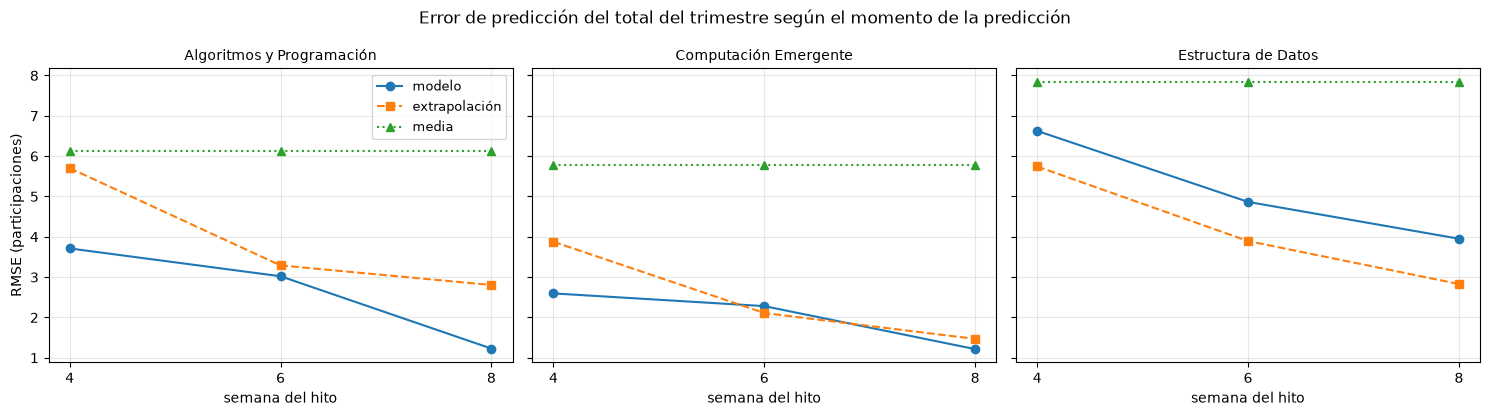

In [28]:
# Generación del gráfico de evolución
graficar_evolucion(resultados)

### 4.3. Valores predichos frente a observados

La dispersión revela el sesgo característico de una variable con muchos ceros y una cola
larga: conviene comprobar si el modelo tiende a subestimar a los estudiantes de
participación alta, que son pocos pero los de mayor interés.

In [29]:
def graficar_dispersion(predicciones, hito):
    """Comparar los valores predichos con los observados en un hito.

    Parameters
    ----------
    predicciones : dict
        Predicciones acumuladas por asignatura e hito.
    hito : int
        Hito que se representa.
    """
    materias = sorted({m for m, h in predicciones if h == hito})
    figura, ejes = plt.subplots(1, len(materias), figsize=(5 * len(materias), 4.4))
    ejes = np.atleast_1d(ejes)

    for eje, materia in zip(ejes, materias):
        salida = predicciones[(materia, hito)]
        eje.scatter(salida["real"], salida["modelo"], alpha=0.5, s=28)
        tope = max(salida["real"].max(), salida["modelo"].max())
        eje.plot([0, tope], [0, tope], "k--", linewidth=1, label="predicción perfecta")
        eje.set_title(materia, fontsize=10)
        eje.set_xlabel("participaciones observadas")
        eje.grid(alpha=0.3)

    ejes[0].set_ylabel("participaciones predichas")
    ejes[0].legend(fontsize=9)
    figura.suptitle(f"Predicción del total del trimestre a la semana {hito}")
    figura.tight_layout()
    plt.show()

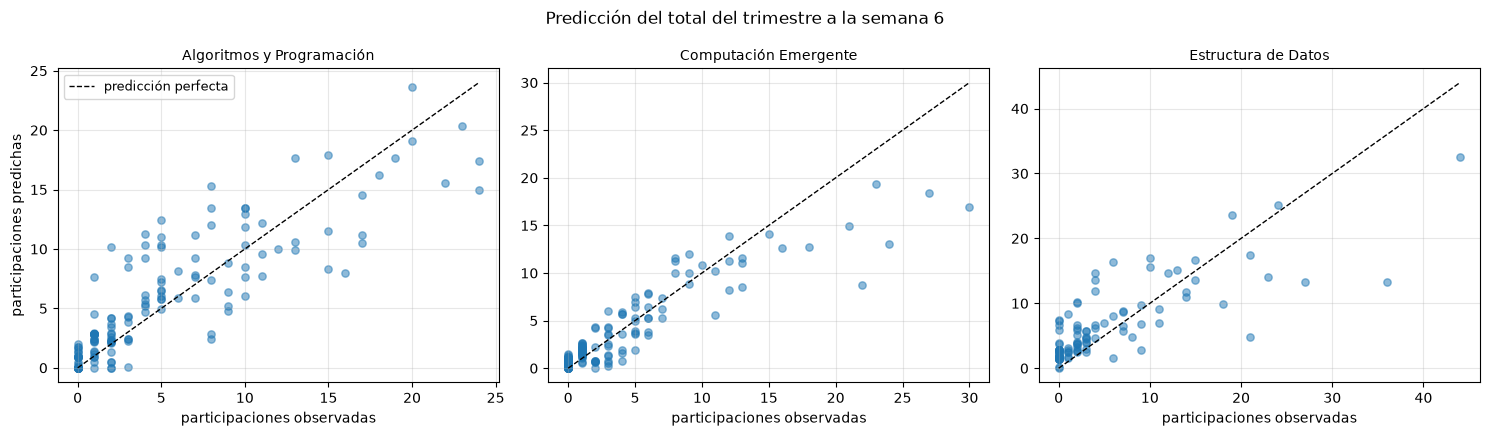

In [30]:
# Dispersión en el hito intermedio
graficar_dispersion(predicciones, HITOS[1])

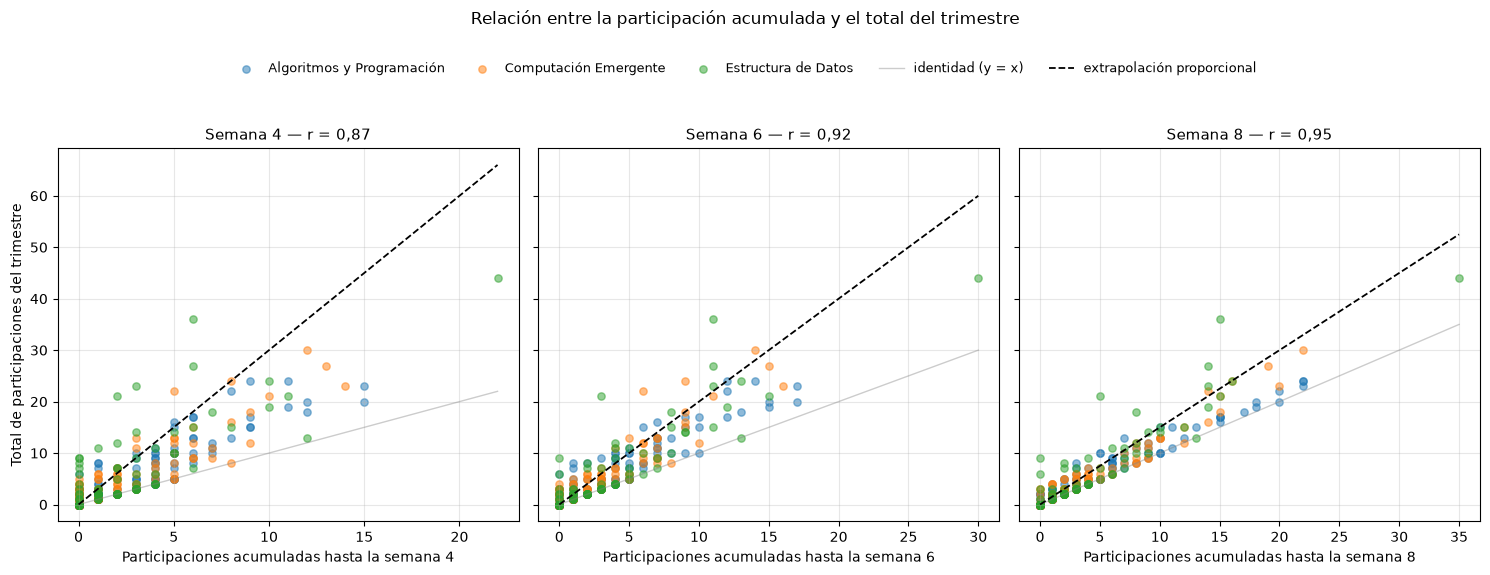

Correlaciones entre el acumulado y el total del trimestre:
  semana 4: r = 0,87
  semana 6: r = 0,92
  semana 8: r = 0,95


In [31]:
# Dispersión entre lo acumulado hasta cada hito y el total del trimestre, por asignatura
COL_PARTICIPACIONES = len(ESTATICAS)
materias = sorted(estatica.materia.unique())
colores = dict(zip(materias, plt.cm.tab10.colors))

figura, ejes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
correlaciones = {}

for eje, hito in zip(ejes, HITOS):
    acumulado = X[:, :hito, COL_PARTICIPACIONES].sum(axis=1)
    r = np.corrcoef(acumulado, y)[0, 1]
    correlaciones[hito] = r

    for materia in materias:
        mascara = (estatica.materia == materia).to_numpy()
        eje.scatter(acumulado[mascara], y[mascara], alpha=0.5, s=28,
                   color=colores[materia], label=materia)

    tope = acumulado.max()
    x_linea = np.linspace(0, tope, 100)
    eje.plot(x_linea, x_linea, color="gray", linewidth=1, alpha=0.4,
             label="identidad (y = x)" if hito == HITOS[0] else None)
    eje.plot(x_linea, x_linea * (12 / hito), "k--", linewidth=1.3,
             label="extrapolación proporcional" if hito == HITOS[0] else None)

    eje.set_title(f"Semana {hito} — r = {r:.2f}".replace(".", ","), fontsize=11)
    eje.set_xlabel(f"Participaciones acumuladas hasta la semana {hito}")
    eje.grid(alpha=0.3)

ejes[0].set_ylabel("Total de participaciones del trimestre")

handles, labels = ejes[0].get_legend_handles_labels()
figura.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
             ncol=len(materias) + 2, fontsize=9, frameon=False)
figura.suptitle("Relación entre la participación acumulada y el total del trimestre", y=1.14)
figura.tight_layout()
figura.savefig("figura_correlacion_acumulado_total.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlaciones entre el acumulado y el total del trimestre:")
for hito in HITOS:
    print(f"  semana {hito}: r = {correlaciones[hito]:.2f}".replace(".", ","))

### 4.4. Registro de las métricas

Las métricas se guardan junto al cuaderno para poder citarlas en el informe sin volver a
entrenar, y porque el entrenamiento no es determinista entre versiones de la biblioteca
aunque la semilla esté fijada.

In [32]:
# Registro de los resultados junto al cuaderno
salida = Path.cwd() / "metricas_adaptacion.csv"
resultados.round(4).to_csv(salida, index=False)
print(f"guardado en {salida}")
resultados.round(3)

guardado en /Users/nelsoncarrillo/Downloads/tesis-prediccion-participacion/LSTM/nuevo/metricas_adaptacion.csv


,materia,hito,fuente,rmse,mae,r2
0,Algoritmos y Programación,4,modelo,3.711,2.788,0.595
1,Algoritmos y Programación,4,media,6.115,4.681,-0.100
2,Algoritmos y Programación,4,extrapolación,5.702,3.707,0.044
3,Algoritmos y Programación,6,modelo,3.021,2.164,0.731
4,Algoritmos y Programación,6,media,6.115,4.681,-0.100
5,Algoritmos y Programación,6,extrapolación,3.290,2.156,0.682
6,Algoritmos y Programación,8,modelo,1.228,0.843,0.956
7,Algoritmos y Programación,8,media,6.115,4.681,-0.100
8,Algoritmos y Programación,8,extrapolación,2.804,1.752,0.769
9,Computación Emergente,4,modelo,2.596,1.749,0.767


## Limitaciones de esta adaptación

Cuatro asuntos quedan documentados como limitaciones y no como resultados.

**El volumen.** Aun con 16 unidades por capa el modelo ajusta cerca de cuatro mil
parámetros sobre poco más de un centenar de registros por asignatura. La validación
cruzada mitiga la dependencia de una partición concreta, pero no crea observaciones. Por
la misma razón el vector de cada tema se limita a dos dimensiones.

**La distribución del objetivo.** El 34% de los registros no tiene ninguna participación
y la media es de 4,27 con un máximo de 44. Una variable así, con exceso de ceros y cola
larga, penaliza a un modelo entrenado con error cuadrático medio, que tiende hacia la
media. Es una razón más para leer el coeficiente de determinación siempre junto a las
líneas base.

**El diseño se eligió con los mismos datos que lo evalúan.** Se probaron tres versiones
sucesivas —sin estandarizar el objetivo, estandarizándolo, y prediciendo las participaciones
restantes en lugar del total— y se adoptó la de mejor desempeño sobre esta misma validación
cruzada. Con 437 registros no hay forma de apartar un conjunto que no haya intervenido en
ninguna decisión, así que las métricas son ligeramente optimistas. La comparación con la
extrapolación no se ve afectada: se calcula sobre las mismas particiones.

**La semilla.** Cada modelo de la sección 3.4 se entrenó con una única semilla. Con un centenar
de registros por asignatura la inicialización puede mover las métricas, así que la sección 3.6
repite el barrido con cinco semillas y reporta media y desviación; esa es la cifra que debe
citarse como resultado.